In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Automobile.csv")
df.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


In [3]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  


In [4]:
print("\nShape of the dataset:", df.shape)
print("Size of the dataset:", df.size)


Shape of the dataset: (398, 9)
Size of the dataset: 3582


In [5]:
print(df.isnull().sum())

name            0
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [6]:

df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

name            0
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [7]:
print("\nShape of Data:", df.shape)
print("Total Elements:", df.size)


Shape of Data: (398, 9)
Total Elements: 3582


In [8]:
print(df.dtypes)

name                str
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
dtype: object


In [9]:
if 'engine-location' in df.columns:
    df['engine-location'] = df['engine-location'].astype('category')

if 'horsepower' in df.columns:
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

print("\nAfter Normalization:")
df.head()


After Normalization:


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0,usa
1,buick skylark 320,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0,usa
2,plymouth satellite,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0,usa
3,amc rebel sst,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0,usa
4,ford torino,0.212766,1.0,0.604651,0.510870,0.520556,0.148810,0.0,usa


In [12]:
df_encoded = pd.get_dummies(df) #“get_dummies() performs one-hot encoding by converting categorical variables into multiple binary columns so that machine learning models can process them.”
print("\nAfter Encoding:")
df_encoded.head()


After Encoding:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name_amc ambassador brougham,name_amc ambassador dpl,name_amc ambassador sst,...,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom,origin_europe,origin_japan,origin_usa
0,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0.212766,1.0,0.604651,0.510870,0.520556,0.148810,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True


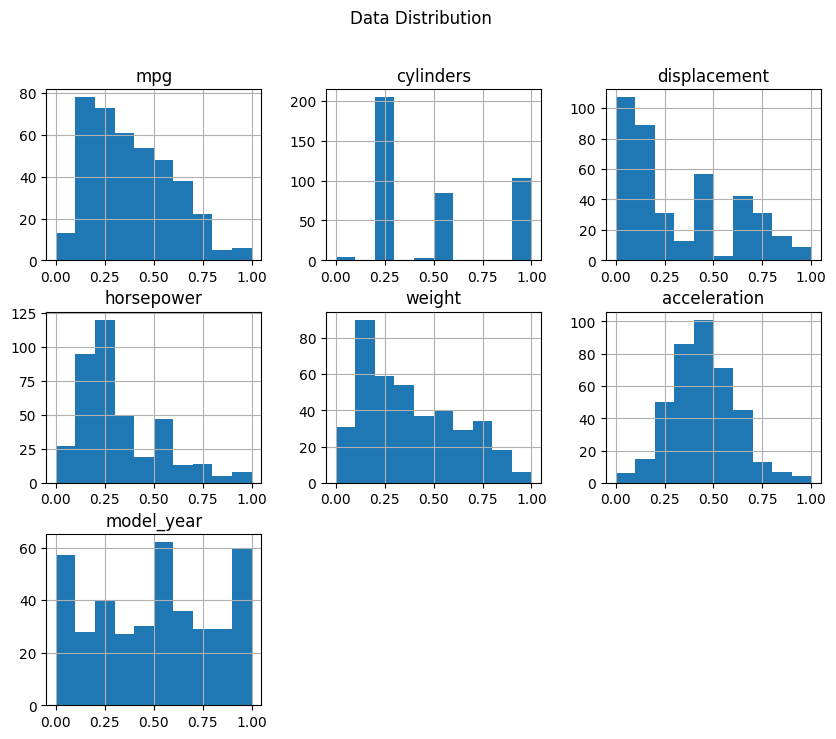

In [13]:
#“This function plots histograms for all numerical features to understand their distribution.”
df_encoded.hist(figsize=(10,8))
plt.suptitle("Data Distribution")
plt.show()

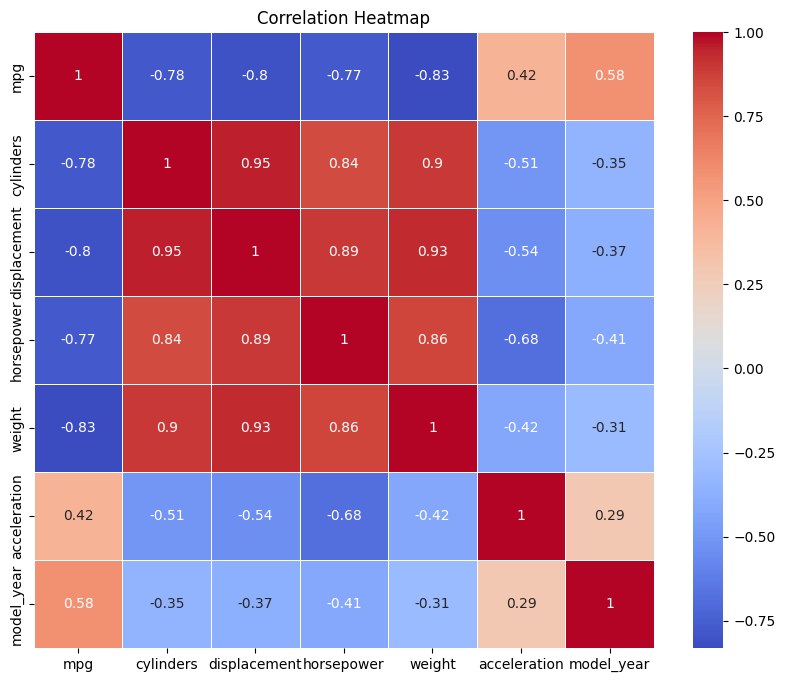

In [14]:
plt.figure(figsize=(10,8))
new_df = df_encoded.select_dtypes(include=np.number)#ecoding because we select only numerical values
sns.heatmap(new_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5) #calculate corelation matrix
plt.title("Correlation Heatmap")
plt.show()